In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd ..
%cd /content/drive/MyDrive

Mounted at /content/drive
/
/content/drive/MyDrive


In [2]:
!pwd
!ls

/content/drive/MyDrive
 best_model.pkl
 bimlendr_arpit_assignment1_bonus.ipynb
 bimlendr_arpitmit_assignment1_part1_diamond.ipynb
 bimlendr_arpitmit_assignment1_part_3_ridge_regression.ipynb
'bimlendr_assignment0_final (1).ipynb'
 bimlendr_Final_part4main.ipynb
 bonus.ipynb
'Colab Notebooks'
 compressed_image1.png
'Contact Information.gform'
'Copy of bimlendr_arpit_assignment1_part1_emission.ipynb'
'Copy of Bimlendr_Assignment1_checkpoint_diamond.ipynb'
'Copy of Bimlendr_Assignment1_checkpoint_emissionbycountry.ipynb'
 diamond.csv
 diamond_processed.csv
 emissions_by_country.csv
 emissions_by_country_processed.csv
 image1_done.png
 image1.png
 image2_done.png
 image2.png
 linear_regression.csv
 linear_regression_done.csv
 New_York_State_Statewide_COVID-19_Testing__Archived__20241009.csv
 penguins.csv
 recolored_image2.png
'Untitled document.gdoc'


In [3]:
#1 Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# 2. Read, preprocess, and print the main statistics about the dataset.
df = pd.read_csv('emissions_by_country.csv')
df.describe()

,Year,Total,Temperature,GDP Per Capita (USD),Coal,Oil,Gas,Cement,Flaring,Other,Per Capita
count,62307.000000,62381.000000,63104.000000,63104.000000,21797.000000,21774.000000,21717.000000,20488.000000,21338.000000,2685.000000,19392.000000
mean,1888.267097,73.683456,49.497813,39026.539015,127.387271,153.480038,125.162671,62.599364,56.074327,849.395127,121.565443
std,122.651184,843.930381,17.292092,10975.539432,677.951392,670.830891,514.391435,353.918064,337.629062,1055.250022,489.339877
min,1003.000000,0.000000,20.000000,20000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1816.000000,0.000000,35.000000,29498.750000,0.000000,0.113584,0.000000,0.000000,0.000000,1.016000,0.231702
50%,1886.000000,0.000000,49.000000,39067.000000,0.344416,1.344688,0.000000,0.032709,0.000000,9.237945,1.601436
75%,1955.000000,0.659520,64.000000,48544.250000,8.500480,13.008908,1.683510,0.725079,0.000000,1812.000000,6.305100
max,2999.000000,37123.850352,79.000000,57999.000000,15051.512770,12345.653374,7921.829472,2982.000000,2994.000000,2999.000000,2997.000000


In [5]:
# 3. Handle missing entries
numColumns = ['Year', 'Total', 'Temperature', 'GDP Per Capita (USD)', 'Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Other', 'Per Capita']
df[numColumns] = df[numColumns].apply(pd.to_numeric,errors='coerce')
dfMean = df.copy()
dfMean[numColumns] = dfMean[numColumns].fillna(dfMean[numColumns].mean())
dfMean

,Country,ISO 3166-1 alpha-3,Year,Total,Temperature,GDP Per Capita (USD),Coal,Oil,Gas,Cement,Flaring,Other,Per Capita
0,Afghanistan,AFG,1750.0,0.000000,70,55455,127.387271,153.480038,125.162671,62.599364,56.074327,849.395127,121.565443
1,Afghanistan,AFG,1751.0,0.000000,66,45101,127.387271,153.480038,125.162671,62.599364,56.074327,849.395127,121.565443
2,Afghanistan,AFG,1752.0,0.000000,72,31891,127.387271,153.480038,125.162671,62.599364,56.074327,849.395127,121.565443
3,Afghanistan,AFG,1753.0,0.000000,44,35466,127.387271,153.480038,125.162671,62.599364,56.074327,849.395127,121.565443
4,Afghanistan,AFG,1754.0,0.000000,21,33247,127.387271,153.480038,125.162671,62.599364,56.074327,849.395127,121.565443
...,...,...,...,...,...,...,...,...,...,...,...,...,...
63099,Global,WLD,2017.0,36096.739276,22,32659,14506.973805,12242.627935,7144.928128,1507.923185,391.992176,302.294047,4.749682
63100,Global,WLD,2018.0,36826.506600,44,21696,14746.830688,12266.016285,7529.846784,1569.218392,412.115746,302.478706,4.792753
63101,Global,WLD,2019.0,37082.558969,78,52918,14725.978025,12345.653374,7647.528220,1617.506786,439.253991,306.638573,4.775633
63102,Global,WLD,2020.0,35264.085734,34,39808,14174.564010,11191.808551,7556.290283,1637.537532,407.583673,296.301685,4.497423


In [6]:
# 4. Handle mismatched string formats.
dfMean['Country'] = dfMean['Country'].str.upper()
dfMean['ISO 3166-1 alpha-3'] = dfMean['ISO 3166-1 alpha-3'].str.upper()
dfMean

,Country,ISO 3166-1 alpha-3,Year,Total,Temperature,GDP Per Capita (USD),Coal,Oil,Gas,Cement,Flaring,Other,Per Capita
0,AFGHANISTAN,AFG,1750.0,0.000000,70,55455,127.387271,153.480038,125.162671,62.599364,56.074327,849.395127,121.565443
1,AFGHANISTAN,AFG,1751.0,0.000000,66,45101,127.387271,153.480038,125.162671,62.599364,56.074327,849.395127,121.565443
2,AFGHANISTAN,AFG,1752.0,0.000000,72,31891,127.387271,153.480038,125.162671,62.599364,56.074327,849.395127,121.565443
3,AFGHANISTAN,AFG,1753.0,0.000000,44,35466,127.387271,153.480038,125.162671,62.599364,56.074327,849.395127,121.565443
4,AFGHANISTAN,AFG,1754.0,0.000000,21,33247,127.387271,153.480038,125.162671,62.599364,56.074327,849.395127,121.565443
...,...,...,...,...,...,...,...,...,...,...,...,...,...
63099,GLOBAL,WLD,2017.0,36096.739276,22,32659,14506.973805,12242.627935,7144.928128,1507.923185,391.992176,302.294047,4.749682
63100,GLOBAL,WLD,2018.0,36826.506600,44,21696,14746.830688,12266.016285,7529.846784,1569.218392,412.115746,302.478706,4.792753
63101,GLOBAL,WLD,2019.0,37082.558969,78,52918,14725.978025,12345.653374,7647.528220,1617.506786,439.253991,306.638573,4.775633
63102,GLOBAL,WLD,2020.0,35264.085734,34,39808,14174.564010,11191.808551,7556.290283,1637.537532,407.583673,296.301685,4.497423


outliers based on Per Capita 1158
new_df size 63104


<Axes: ylabel='Per Capita'>

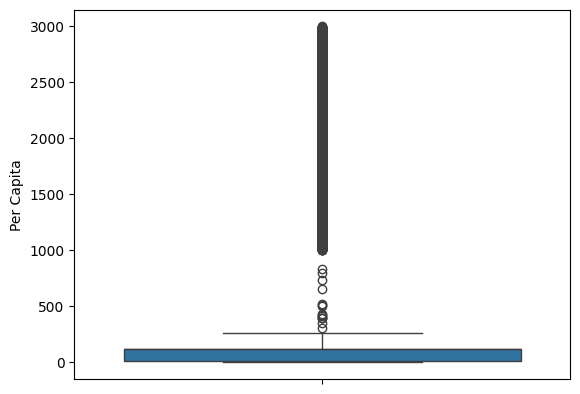

In [7]:
#5. Handle outliers.
def detectOutliers(df, column):
    quartile1 = df[column].quantile(0.25)
    quartile3 = df[column].quantile(0.75)
    interQuartileRange = quartile3 - quartile1
    lowerLimit = quartile1 - (1.5 * interQuartileRange)
    upperLimit = quartile3 + (1.5 * interQuartileRange)
    outliers = df[(df[column] < lowerLimit) | (df[column] > upperLimit)]
    return outliers, lowerLimit, upperLimit

outliers, lower, upper = detectOutliers(dfMean, 'Per Capita')
new_df = dfMean.copy()
mean_PCapita = new_df[(new_df['Per Capita'] >= lower) & (new_df['Per Capita'] <= upper)]['Per Capita'].mean()
new_df['Per Capita'] = new_df['Per Capita'].apply(
    lambda x: mean_PCapita if x < lower or x > upper else x
)
print('outliers based on Per Capita', len(outliers))
print('new_df size', len(new_df))
# 6. Visualization Graph
sns.boxplot(dfMean['Per Capita'])

<Axes: ylabel='Per Capita'>

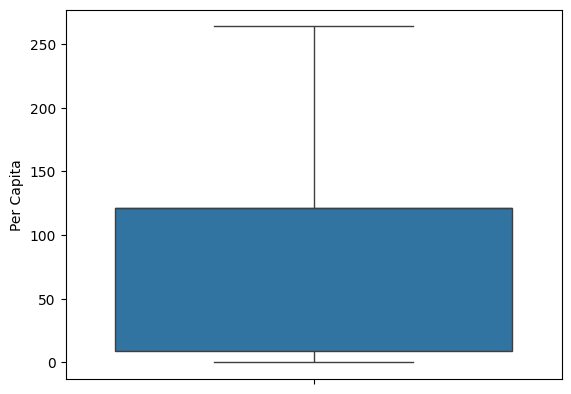

In [8]:
sns.boxplot(new_df['Per Capita'])

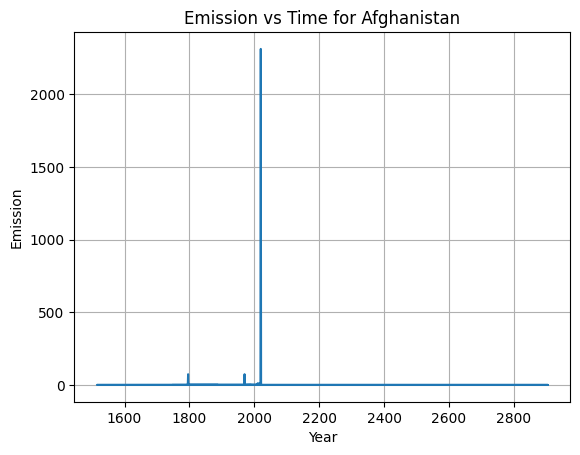

In [9]:
countryData = new_df[new_df['Country'] == 'AFGHANISTAN']
plt.plot(countryData['Year'], countryData['Total'])
plt.title('Emission vs Time for Afghanistan')
plt.xlabel('Year')
plt.ylabel('Emission')
plt.grid(True)
plt.show()

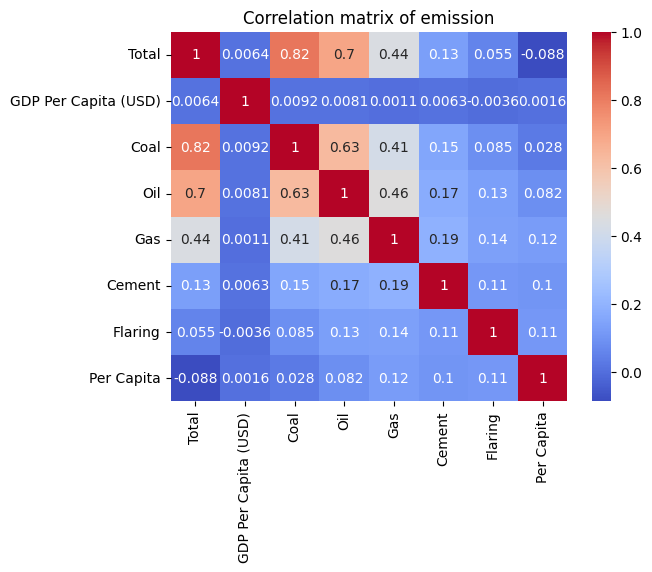

In [10]:
correlation = new_df[['Total', 'GDP Per Capita (USD)', 'Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Per Capita']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation matrix of emission')
plt.show()

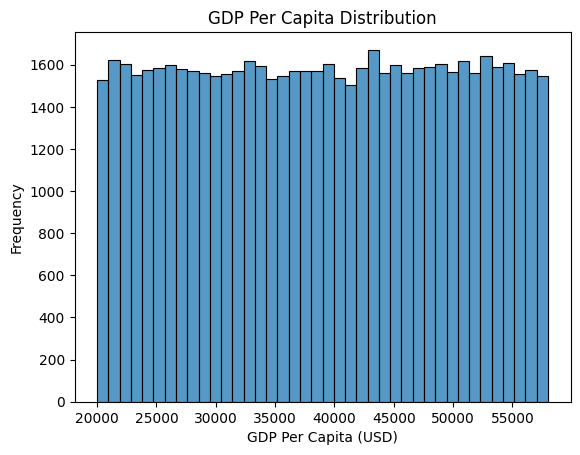

In [11]:
sns.histplot(new_df['GDP Per Capita (USD)'])
plt.title('GDP Per Capita Distribution')
plt.xlabel('GDP Per Capita (USD)')
plt.ylabel('Frequency')
plt.show()

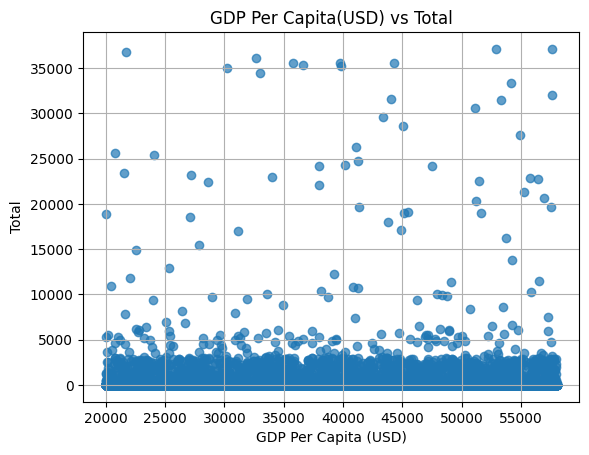

In [12]:
plt.scatter(new_df['GDP Per Capita (USD)'], new_df['Total'], alpha=0.7)
plt.title('GDP Per Capita(USD) vs Total')
plt.xlabel('GDP Per Capita (USD)')
plt.ylabel('Total')
plt.grid(True)
plt.show()

In [13]:
# 7. Identify uncorrelated or unrelated features.
medianTotal = new_df['Total'].median()
new_df['High_Emissions'] = np.where(new_df['Total'] > medianTotal, 1, 0)
numberColumn = new_df.select_dtypes(include=[np.number])
correlationMatrix = numberColumn.corr()
correlationHE = correlationMatrix['High_Emissions'].sort_values(ascending=False)
print(correlationHE)
new_df

High_Emissions          1.000000
Year                    0.419721
Total                   0.117274
Temperature             0.002663
GDP Per Capita (USD)   -0.002198
Coal                   -0.050103
Cement                 -0.070080
Oil                    -0.088837
Flaring                -0.095072
Other                  -0.106264
Gas                    -0.122446
Per Capita             -0.732633
Name: High_Emissions, dtype: float64


,Country,ISO 3166-1 alpha-3,Year,Total,Temperature,GDP Per Capita (USD),Coal,Oil,Gas,Cement,Flaring,Other,Per Capita,High_Emissions
0,AFGHANISTAN,AFG,1750.0,0.000000,70,55455,127.387271,153.480038,125.162671,62.599364,56.074327,849.395127,121.565443,0
1,AFGHANISTAN,AFG,1751.0,0.000000,66,45101,127.387271,153.480038,125.162671,62.599364,56.074327,849.395127,121.565443,0
2,AFGHANISTAN,AFG,1752.0,0.000000,72,31891,127.387271,153.480038,125.162671,62.599364,56.074327,849.395127,121.565443,0
3,AFGHANISTAN,AFG,1753.0,0.000000,44,35466,127.387271,153.480038,125.162671,62.599364,56.074327,849.395127,121.565443,0
4,AFGHANISTAN,AFG,1754.0,0.000000,21,33247,127.387271,153.480038,125.162671,62.599364,56.074327,849.395127,121.565443,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63099,GLOBAL,WLD,2017.0,36096.739276,22,32659,14506.973805,12242.627935,7144.928128,1507.923185,391.992176,302.294047,4.749682,1
63100,GLOBAL,WLD,2018.0,36826.506600,44,21696,14746.830688,12266.016285,7529.846784,1569.218392,412.115746,302.478706,4.792753,1
63101,GLOBAL,WLD,2019.0,37082.558969,78,52918,14725.978025,12345.653374,7647.528220,1617.506786,439.253991,306.638573,4.775633,1
63102,GLOBAL,WLD,2020.0,35264.085734,34,39808,14174.564010,11191.808551,7556.290283,1637.537532,407.583673,296.301685,4.497423,1


In [14]:
threshold = 0.1
lowerCorrelations = correlationHE[correlationHE.abs() < threshold].index.tolist()
df_ToDrop = new_df.copy()
df_ToDrop = df_ToDrop.drop(columns=lowerCorrelations)
print("low correlation ", lowerCorrelations)
df_ToDrop

low correlation  ['Temperature', 'GDP Per Capita (USD)', 'Coal', 'Cement', 'Oil', 'Flaring']


,Country,ISO 3166-1 alpha-3,Year,Total,Gas,Other,Per Capita,High_Emissions
0,AFGHANISTAN,AFG,1750.0,0.000000,125.162671,849.395127,121.565443,0
1,AFGHANISTAN,AFG,1751.0,0.000000,125.162671,849.395127,121.565443,0
2,AFGHANISTAN,AFG,1752.0,0.000000,125.162671,849.395127,121.565443,0
3,AFGHANISTAN,AFG,1753.0,0.000000,125.162671,849.395127,121.565443,0
4,AFGHANISTAN,AFG,1754.0,0.000000,125.162671,849.395127,121.565443,0
...,...,...,...,...,...,...,...,...
63099,GLOBAL,WLD,2017.0,36096.739276,7144.928128,302.294047,4.749682,1
63100,GLOBAL,WLD,2018.0,36826.506600,7529.846784,302.478706,4.792753,1
63101,GLOBAL,WLD,2019.0,37082.558969,7647.528220,306.638573,4.775633,1
63102,GLOBAL,WLD,2020.0,35264.085734,7556.290283,296.301685,4.497423,1


In [15]:
# 8. Convert features with string datatype to categorical
onHotEncoding = pd.get_dummies(df_ToDrop, columns=['Country', 'ISO 3166-1 alpha-3'], drop_first=True)
onHotEncoding.head(5)

,Year,Total,Gas,Other,Per Capita,High_Emissions,Country_ALBANIA,Country_ALGERIA,Country_ANDORRA,Country_ANGOLA,...,ISO 3166-1 alpha-3_VNM,ISO 3166-1 alpha-3_VUT,ISO 3166-1 alpha-3_WLD,ISO 3166-1 alpha-3_WLF,ISO 3166-1 alpha-3_WSM,ISO 3166-1 alpha-3_XIT,ISO 3166-1 alpha-3_YEM,ISO 3166-1 alpha-3_ZAF,ISO 3166-1 alpha-3_ZMB,ISO 3166-1 alpha-3_ZWE
0,1750.0,0.0,125.162671,849.395127,121.565443,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1751.0,0.0,125.162671,849.395127,121.565443,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1752.0,0.0,125.162671,849.395127,121.565443,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1753.0,0.0,125.162671,849.395127,121.565443,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1754.0,0.0,125.162671,849.395127,121.565443,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [16]:
# 9. Normalize non-categorical features
minimumOneHot = onHotEncoding.min()
maximumOneHot = onHotEncoding.max()
normalized = onHotEncoding.copy()
for column in normalized.columns:
    if normalized[column].dtype in ['float64', 'int64']:
        normalized[column] = (normalized[column] - minimumOneHot[column]) / (maximumOneHot[column] - minimumOneHot[column])
normalized

,Year,Total,Gas,Other,Per Capita,High_Emissions,Country_ALBANIA,Country_ALGERIA,Country_ANDORRA,Country_ANGOLA,...,ISO 3166-1 alpha-3_VNM,ISO 3166-1 alpha-3_VUT,ISO 3166-1 alpha-3_WLD,ISO 3166-1 alpha-3_WLF,ISO 3166-1 alpha-3_WSM,ISO 3166-1 alpha-3_XIT,ISO 3166-1 alpha-3_YEM,ISO 3166-1 alpha-3_ZAF,ISO 3166-1 alpha-3_ZMB,ISO 3166-1 alpha-3_ZWE
0,0.374248,0.000000,0.015800,0.283226,0.460348,0.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0.374749,0.000000,0.015800,0.283226,0.460348,0.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0.375251,0.000000,0.015800,0.283226,0.460348,0.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0.375752,0.000000,0.015800,0.283226,0.460348,0.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0.376253,0.000000,0.015800,0.283226,0.460348,0.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63099,0.508016,0.972333,0.901929,0.100798,0.017986,1.0,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
63100,0.508517,0.991990,0.950519,0.100860,0.018149,1.0,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
63101,0.509018,0.998888,0.965374,0.102247,0.018085,1.0,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
63102,0.509519,0.949904,0.953857,0.098800,0.017031,1.0,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False


Referenced used:
1. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.apply.html#pandas.DataFrame.apply
2. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html
3. https://matplotlib.org/stable/users/explain/quick_start.html
4. https://seaborn.pydata.org/api.html
5. https://medium.com/@pp1222001/outlier-detection-and-removal-using-the-iqr-method-6fab2954315d
6. https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html